# Audio Signal Preprocessing and Feature Extraction

Note: I wrote in English and Portuguese - sorry about that!

Atenção! Não é preciso seguir todos estes passos para extrair as *features* da fala.

---

Before anything else... import!

In [102]:
pip install librosa

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import librosa
import librosa.display # visualization of audio
import IPython.display as ipd # playing audios
from glob import glob

In [104]:
audio_files = glob('*.wav')
audio_files

['frase5_pt.wav',
 'frase3_pt.wav',
 'frase4_pt.wav',
 'frase2_pt.wav',
 'frase1_pt.wav']

With everything imported, let's see our audio files:

In [105]:
ipd.Audio(audio_files[0]) # chose the audio in position 0 for an example

To actually see and manipulate the **raw data**, you need to "convert" this file to librosa. We will then have the raw data (y) of the file and the integer value of the sample rate (sr).

Essencialmente:
- y - 1D NumPy array with the **amplitude** of the audio signal at every single point in time. These numbers represent how much the microphone diaphragm pushed or pulled in the track. By default, Librosa automatically converts the audio to mono and normalizes the volume so that all values fall between -1.0 and 1.0.

- sr - Integer representing the number of audio samples recorded per second. By default, Librosa downsamples audio to 22,050 Hz (22,050 samples per second) unless you tell it otherwise. -> In this case, it was downsampled because the original sample is 48kHz.

In [106]:
y, sr = librosa.load(audio_files[0])
print(f'y : {y[:10]}') # primeiras 10 samples
print(f'shape y : {y.shape}') # total length of the 'y' array
print(f'sr {sr}') # value of the sample rate of the audio

y : [-3.9826041e-06 -2.4782014e-06  3.6238850e-06  2.6919088e-06
  5.6639392e-06 -7.8425182e-06  1.6798774e-06  4.6990754e-06
  4.5546844e-06 -7.3205183e-07]
shape y : (70892,)
sr 22050


Notas importantes:
- `e-06` nos números é a notação científica. Ou seja, *(-10).
Logo, os primeiros números, `-3.9826041e-06`e `-2.4782014e-06` são os mesmos que `-0.0000039826041` e `-0.000004782014`. Isto significa que, já que o volume está entre `-1.0` (valor máximo negativo) e `1.0` (valor máximo positivo),o arquivo começa quase em **silêncio absoluto** por estar tão perto de 0.

- o 'shape' especificado na linha 3 do código acima serve para nos dizer qual é o número total de samples do áudio. Neste caso, o áudio tem 70892 samples.

- Sample rate e samples são coisas diferentes. A sample rate especifica o **número de samples necessárias** para **1 segundo** (neste caso, 22050 samples). Contudo, o número total de samples pode ser maior ou menor dependendo de quantos segundos tem o ficheiro. Neste áudio, o número total de samples é maior do que a sample rate pelo simples facto de que o áudio tem cerca de 3 segundos e não 1 segundo.

Now let's plot our raw data into a **waveform plot**:
- transforming the 1D numpy array to a pandas Series (because it's easier to plot);
- giving the plot a `figsize` of 10x5;
- giving the `lw` a weidth of 1;
- giving a random title;
- using `plt.show()` to show our waveform.

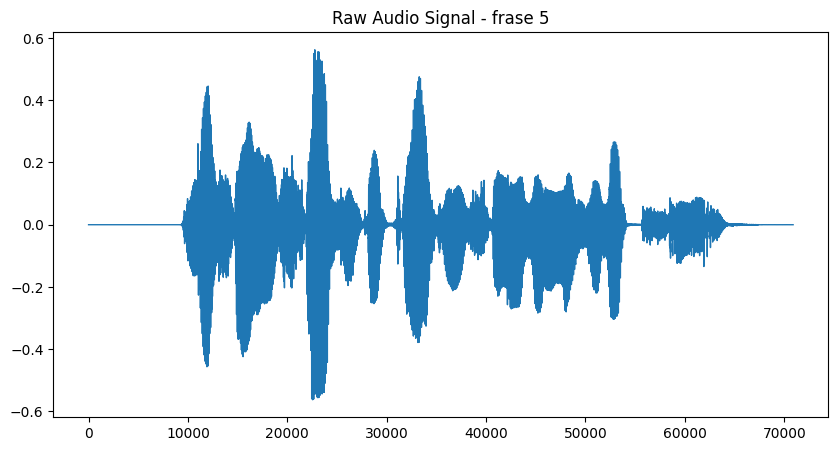

In [107]:
pd.Series(y).plot(figsize=(10, 5), lw=1, title='Raw Audio Signal - frase 5')
plt.show()

We can also zoom in the plot choosing a sample window (in this case, from 10000 to 11000 samples, so a window of 100 samples.

Warning: remember that this plot is presenting the x-axis with the samples by order of the list (0,1,2, etc), which could be equivalent to a time window.

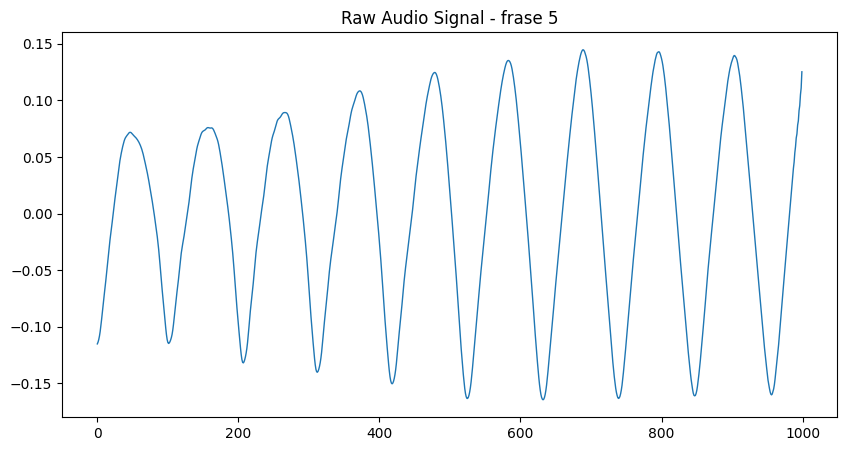

In [108]:
pd.Series(y[10000:11000]).plot(figsize=(10, 5), lw=1, title='Raw Audio Signal - frase 5')
plt.show()

Como transformar o nosso áudio para dados de espectrograma:
- `librosa.stft(y)` - o método `stft` da package `librosa` faz o **Short-Time Fourier Transform (STFT)** no áudio. O STFT divide o áudio em centenas (ou milhares, dependendo do tamanho, em termos de tempo, do áudio) de pedaços de tempo sobrepostos. Para cada pedaço, calcula a quantidade de graves, médios e agudos presentes.

- `np.abs(audio_stft)` - extrai o valor absoluto dos números complexos, isolando apenas a amplitude (a força de cada frequência) e descartando a fase.

- `librosa.amplitude_to_db(...)`- converte a amplitude para Decibéis (dB), que é uma escala logarítmica. A audição humana não percebe o volume de forma linear - nós ouvimos de forma logarítmica. Esta conversão garante que os dados matemáticos correspondam à forma como o ouvido humano realmente percebe a intensidade do som.

- `ref = np.max` -  Define o som mais alto deste áudio como o ponto de referência de 0dB. Tudo o que for mais silencioso do que esse pico será representado por números negativos (ex: -20dB, -80dB).

> O resultado é uma matriz de números complexos (1) cujas linhas são as frequências do áudio e as colunas são os tempos, sendo que cada célula relaciona cada frequência com o tempo do áudio para dar um valor de volume.

---
(1) Números complexos são números com uma parte real e uma imaginária, com a seguinte estrutura: `a+bi`, em que `i=-1`.

In [109]:
audio_stft = librosa.stft(y)
audio_db = librosa.amplitude_to_db(np.abs(audio_stft), ref = np.max)
audio_db.shape

(1025, 139)

O output de `audio_db.shape` diz-nos que temos uma matriz com 1025 linhas (cada linha sendo uma frequência específica) e 139 colunas (cada "pedaço" do meu áudio, também conhecido como *frame*). No total, a matriz contém `1025 x 139 = 142,475`células, que é a informação de **volume em Decibéis** naquela exata frequência e naquele exato momento do tempo.

Para realmente fazer plot do espectrograma do áudio, podemos usar o matplotlib:

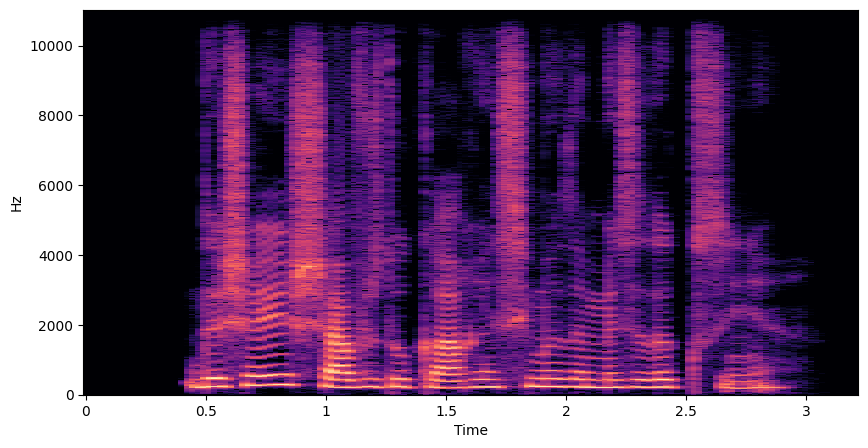

In [110]:
# Ploting the transformed audio data
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(audio_db,
                               sr=sr,
                               x_axis='time',
                               y_axis='hz',
                               ax=ax)

## **Time for a bit of learning**:

### O que é a Fourier Transform (FT)?
Basicamente, é um conceito matemático, com a respetiva fórmula, que simplifica uma **onda complexa** nas suas frequências constituintes.

### Aonde é que entram a Fast Fourier Transform (FFT) e a Short-Time Fourier Transform (STFT)?
Se a Fourier Transform (FT) é a matemática pura, o FFT é apenas uma algoritmo super otimizado da FT. É importante perceber a desvantagem da FT e da FFT: elas "desmontam" a onda complexa nas suas frequências, mas ignoram completamente o seu alinhamento com o tempo (portanto, a sua fase). Ou seja, não conseguem perceber *quando* determinada frequência tem uma intensidade maior ou menor (volume).
É aqui que entra a STFT. Para contornar este problema do tempo, o algoritmo corta primeiro várias partes do áudio, sobrepostas, para que se consiga "desmontar" a onda complexa num período de tempo EXTREMAMENTE mais pequena, a ponto de termos a certeza sobre a fase da onda relativamente ao tempo.

BAAAM! (1)

## Outras notas importantes
Como falei em números complexos, é importante explicar que o **ângulo** do vetor do número complexo diz-nos a fase da onda e o comprimento (valor absoluto) desse vetor dá-nos a **intensidade** da frequência. No entanto, como vimos no código acima, o algoritmo descarta a fase, visto não ser necessário para o espectrograma.

(1) Referência ao canal de youtube [StatQuest](https://www.youtube.com/@statquest)


### Extrair features
Como disse logo no início do notebook, não é preciso fazer estes passos todos. Em vez de usarmos funções para alterar a escala de volume linear em Decibéis e gerar uma matriz (portanto, fazer uma STFT manual), podemos apenas **usar `librosa.feature.mfcc(...)`**. Esta função para os MFCC (Mel-Frequency Cepstral Coefficients) converte o áudio bruto diretamente para a escala certa.

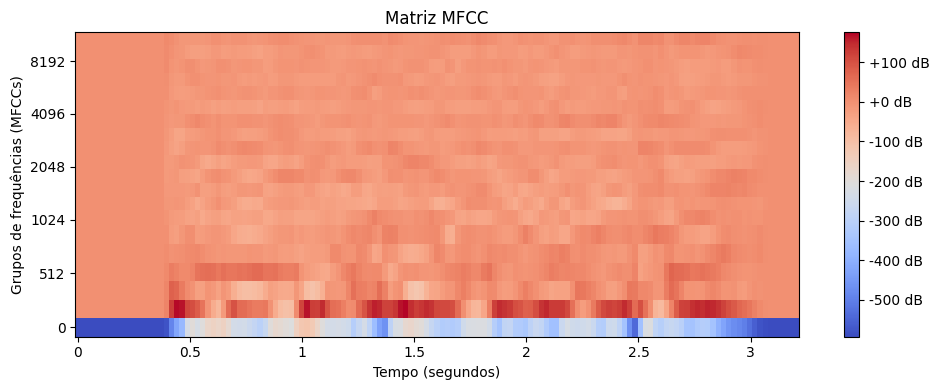

In [111]:
audio_mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
plt.figure(figsize=(10, 4)) # ploting the data
librosa.display.specshow(audio_mfcc,
                         sr=sr,
                         x_axis='time',
                         y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Matriz MFCC')
plt.xlabel('Tempo (segundos)')
plt.ylabel('Grupos de frequências (MFCCs)')
plt.tight_layout()
plt.show()